# AstroVision — Phase 5 : Classificateur Multi-Modal
## Fusion DINOv2 × Morphométrie × Photométrie SDSS

**Objectif :** Dépasser les 0.839 balanced_acc de DINOv2 seul en fusionnant
explicitement les modalités complémentaires.

| Modalité | Dimension | Source |
|---|---|---|
| DINOv2 features | 768 | Notebook 03/04 |
| Morphométrie (C,A,S,Gini,M20) | 5 | Notebook 06 |
| Photométrie SDSS (g-r,u-r,Mr) | 3 | Notebook 05 |

**Architecture Late Fusion :**
```
DINOv2 (768) → MLP → 256 ─┐
Morpho  (5)  → MLP → 32  ─┤ → Concat → MLP → 10 classes
Photo   (3)  → MLP → 16  ─┘
```


## 0 — Imports & Config

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

sys.path.insert(0, str(Path('..').resolve()))
from src.astrovision.fusion import (
    GalaxyFusionClassifier, FusionDataset,
    build_fusion_datasets, train_fusion,
    evaluate_fusion, ablation_study
)
from src.astrovision.synthesis import DARK, CLASS_NAMES, PALETTE

import torch
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DATA_DIR    = Path('../data')
FIGURES_DIR = Path('../figures')
CKPT_DIR    = Path('../checkpoints')
plt.rcParams.update(DARK)
print(f'✅ Setup OK | Device : {DEVICE}')

✅ Setup OK | Device : cuda


## 1 — Chargement des données

In [5]:
import h5py
import torch
from torchvision import transforms

# Labels
with h5py.File(DATA_DIR / 'Galaxy10_DECals.h5', 'r') as f:
    labels_all = f['ans'][:].astype(int)
    images_all = f['images'][:]
print(f'✓ Labels : {len(labels_all):,}')

DINO_PATH = DATA_DIR / 'dino_features.npy'

if DINO_PATH.exists():
    dino_features = np.load(DINO_PATH)
    print(f'✓ DINOv2 chargé depuis cache : {dino_features.shape}')
else:
    print('Extraction features DINOv2 (~5 min)...')

    # Charger le backbone DINOv2 directement depuis le checkpoint fine-tuné
    # Le checkpoint contient le modèle complet — on extrait seulement le backbone
    ckpt_path = CKPT_DIR / 'dinov2_galaxy10_finetune_best.pt'
    
    # Reconstruire l'architecture exacte du notebook 04
    backbone   = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14',
                                 pretrained=False, force_reload=False)
    state_dict = torch.load(ckpt_path, map_location='cpu')
    
    # Garder seulement les clés du backbone (sans la tête de classification)
    backbone_sd = {k.replace('backbone.', ''): v
                   for k, v in state_dict.items()
                   if k.startswith('backbone.')}
    backbone.load_state_dict(backbone_sd, strict=False)
    backbone = backbone.to(DEVICE).eval()
    print(f'✓ Backbone DINOv2 chargé depuis {ckpt_path.name}')

    transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])

    feats_list = []
    BATCH = 128
    with torch.no_grad():
        for i in range(0, len(images_all), BATCH):
            batch = torch.stack([transform(img) for img in images_all[i:i+BATCH]])
            feats = backbone(batch.to(DEVICE))  # (B, 768) — token CLS
            feats_list.append(feats.cpu().numpy())
            print(f'  {min(i+BATCH, len(images_all)):>6}/{len(images_all)}', end='\r')

    dino_features = np.concatenate(feats_list, axis=0)
    np.save(DINO_PATH, dino_features)
    print(f'\n✓ Features sauvegardées : {dino_features.shape}')

# ── Morphométrie — chargement robuste ─────────────────────────────────────────
import os

# Chemins possibles selon comment le notebook 06 a sauvegardé
morph_candidates = [
    DATA_DIR / 'morphometry_df.pkl',
    DATA_DIR / 'morphometry_results.pkl',
    DATA_DIR / 'morphometry_df.csv',
]

morph_df = None
for path in morph_candidates:
    if path.exists():
        morph_df = pd.read_pickle(path) if path.suffix == '.pkl' else pd.read_csv(path)
        print(f'✓ Morphométrie chargée : {morph_df.shape} ← {path.name}')
        break

if morph_df is None:
    print('⚠ morphometry_df.pkl introuvable — calcul CAS/Gini/M20 sur Galaxy10...')
    print('  (≈ 15-20 min selon CPU)')
    from src.astrovision.morphometry import batch_morphometry
    morph_df = batch_morphometry(images_all, labels_all)
    morph_df.to_pickle(DATA_DIR / 'morphometry_df.pkl')
    print(f'✓ Morphométrie calculée et sauvegardée : {morph_df.shape}')

morph_features = morph_df[['C', 'A', 'S', 'Gini', 'M20']].values
print(f'✓ Morphométrie : {morph_features.shape}')

# ── Photométrie SDSS ───────────────────────────────────────────────────────────
sdss_candidates = [
    DATA_DIR / 'galaxy10_sdss_xmatch.csv.gz',
    DATA_DIR / 'galaxy10_sdss_xmatch.csv',
]

photo_features = np.full((len(labels_all), 3), np.nan)  # fallback NaN
for path in sdss_candidates:
    if path.exists():
        sdss_df   = pd.read_csv(path)
        photo_df  = pd.DataFrame({'g10_idx': np.arange(len(labels_all))})
        photo_df  = photo_df.merge(
            sdss_df[['g10_idx','g-r','u-r','Mr']].drop_duplicates('g10_idx'),
            on='g10_idx', how='left'
        )
        photo_features = photo_df[['g-r','u-r','Mr']].values
        n_matched = (~np.isnan(photo_features).any(axis=1)).sum()
        print(f'✓ Photométrie SDSS : {photo_features.shape}  ({n_matched:,} matchées)')
        break
else:
    print('⚠ Aucun cache SDSS trouvé — photométrie désactivée (NaN partout)')
    print('  → Le modèle de fusion fonctionnera avec DINOv2 + Morpho seulement')

✓ Labels : 17,736
✓ DINOv2 chargé depuis cache : (17736, 768)
⚠ morphometry_df.pkl introuvable — calcul CAS/Gini/M20 sur Galaxy10...
  (≈ 10-15 min selon CPU)
  5000/5000  (100.0%) ✓
✓ Morphométrie calculée et sauvegardée : (5000, 13)
✓ Morphométrie : (5000, 5)
✓ Photométrie SDSS : (17736, 3)  (5,651 matchées)


## 2 — Splits train/val/test

In [7]:
# ── Alignement morphométrie → 17 736 galaxies ─────────────────────────────────
# morph_df ne couvre que 5 000 galaxies — on la réindexe sur tout Galaxy10
# Les galaxies sans métriques reçoivent NaN (masquées dans FusionDataset)

print(f'morph_df avant alignement : {morph_df.shape}')

morph_full = pd.DataFrame({'g10_idx': np.arange(len(labels_all))})
morph_full = morph_full.merge(
    morph_df[['g10_idx', 'C', 'A', 'S', 'Gini', 'M20']],
    on='g10_idx', how='left'
)
morph_features = morph_full[['C', 'A', 'S', 'Gini', 'M20']].values

n_ok  = (~np.isnan(morph_features).any(axis=1)).sum()
n_nan = np.isnan(morph_features).any(axis=1).sum()
print(f'morph_features aligné : {morph_features.shape}')
print(f'  Avec métriques : {n_ok:,}  |  NaN (masqués) : {n_nan:,}')

morph_df avant alignement : (5000, 13)
morph_features aligné : (17736, 5)
  Avec métriques : 4,999  |  NaN (masqués) : 12,737


In [8]:
np.random.seed(42)
idx = np.arange(len(labels_all))

# Split stratifié 70/15/15
train_idx, temp_idx = train_test_split(
    idx, test_size=0.30, stratify=labels_all, random_state=42)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, stratify=labels_all[temp_idx], random_state=42)

print(f'Train : {len(train_idx):,}  |  Val : {len(val_idx):,}  |  Test : {len(test_idx):,}')

# Construire les datasets
train_ds, val_ds, test_ds = build_fusion_datasets(
    dino_features, labels_all,
    train_idx, val_idx, test_idx,
    morph_features=morph_features,
    photo_features=photo_features,
)
print('✓ FusionDataset créés')

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=512, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=512, shuffle=False, num_workers=0)

Train : 12,415  |  Val : 2,660  |  Test : 2,661
✓ FusionDataset créés


## 3 — Entraînement du modèle de fusion

In [9]:
model_fusion = GalaxyFusionClassifier(
    n_morph  = morph_features.shape[1],   # 5
    n_photo  = photo_features.shape[1],   # 3
    dropout  = 0.35,
    n_classes= 10,
)

n_params = sum(p.numel() for p in model_fusion.parameters())
print(f'Paramètres : {n_params:,}')

model_fusion = train_fusion(
    model_fusion,
    train_loader, val_loader,
    epochs    = 50,
    lr        = 3e-4,
    ckpt_dir  = str(CKPT_DIR),
    model_name= 'fusion_dinov2_morpho_photo',
    use_wandb = True,
    device    = DEVICE,
)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\alexb\_netrc.


Paramètres : 643,034
════════════════════════════════════════════════════════════
  GalaxyFusionClassifier — DINOv2 + Morphométrie + Photométrie
  Params : 643,034   Device : cuda
════════════════════════════════════════════════════════════



wandb: Currently logged in as: phdbrown (phdbrown-universit-laval) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


[★] Epoch 01/50  Train bal=0.6960 loss=1.2786  |  Val bal=0.8468 loss=0.8438
[★] Epoch 02/50  Train bal=0.8268 loss=0.8855  |  Val bal=0.8725 loss=0.7948
[★] Epoch 03/50  Train bal=0.8527 loss=0.8340  |  Val bal=0.8737 loss=0.7852
[★] Epoch 04/50  Train bal=0.8567 loss=0.8173  |  Val bal=0.8756 loss=0.7804
[ ] Epoch 05/50  Train bal=0.8604 loss=0.8012  |  Val bal=0.8744 loss=0.7811
[ ] Epoch 06/50  Train bal=0.8710 loss=0.7884  |  Val bal=0.8719 loss=0.7836
[ ] Epoch 07/50  Train bal=0.8708 loss=0.7752  |  Val bal=0.8689 loss=0.7777
[★] Epoch 08/50  Train bal=0.8785 loss=0.7628  |  Val bal=0.8768 loss=0.7792
[ ] Epoch 09/50  Train bal=0.8817 loss=0.7552  |  Val bal=0.8733 loss=0.7817
[ ] Epoch 10/50  Train bal=0.8904 loss=0.7434  |  Val bal=0.8714 loss=0.7848
[ ] Epoch 11/50  Train bal=0.8931 loss=0.7350  |  Val bal=0.8716 loss=0.7793
[ ] Epoch 12/50  Train bal=0.8915 loss=0.7298  |  Val bal=0.8761 loss=0.7881
[ ] Epoch 13/50  Train bal=0.9006 loss=0.7208  |  Val bal=0.8738 loss=0.7886

epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
lr,███████▇▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▄▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁
train/balanced_acc,▁▄▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇██████████████████
train/loss,█▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/balanced_acc,▁▇█▇▇█▇▇▇█▇▇▇█▇▇█▅█▇▇█▇▅▇▆▆▇▆▇▇▇▆▇▇▇▆▆▇▆
val/loss,█▃▂▁▁▁▁▂▁▂▂▂▃▃▃▃▄▄▅▅▆▆▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇
epoch,50
lr,0.0
train/balanced_acc,0.96586
train/loss,0.59525
val/balanced_acc,0.87052


## 4 — Évaluation sur le test set

In [11]:
results = evaluate_fusion(model_fusion, test_loader, device=DEVICE)

print(f'\n{"="*55}')
print(f'  RESULTATS FUSION - Test Set')
print(f'{"="*55}')
print(f'  Balanced Accuracy : {results["balanced_acc"]:.4f}')
print(f'  Accuracy          : {results["accuracy"]:.4f}')
print(f'\nRapport par classe :')
print(results['report'])


  RESULTATS FUSION - Test Set
  Balanced Accuracy : 0.8631
  Accuracy          : 0.8752

Rapport par classe :
                         precision    recall  f1-score   support

              Disturbed       0.63      0.59      0.61       162
                Merging       0.92      0.90      0.91       278
           Round Smooth       0.93      0.95      0.94       397
In-between Round Smooth       0.93      0.91      0.92       304
    Cigar Shaped Smooth       0.75      0.86      0.80        50
          Barred Spiral       0.91      0.91      0.91       307
  Unbarred Tight Spiral       0.79      0.83      0.81       275
  Unbarred Loose Spiral       0.80      0.79      0.79       394
  Edge-on without Bulge       0.94      0.93      0.94       213
     Edge-on with Bulge       0.96      0.97      0.97       281

               accuracy                           0.88      2661
              macro avg       0.86      0.86      0.86      2661
           weighted avg       0.87      0.

## 5 — Matrice de confusion

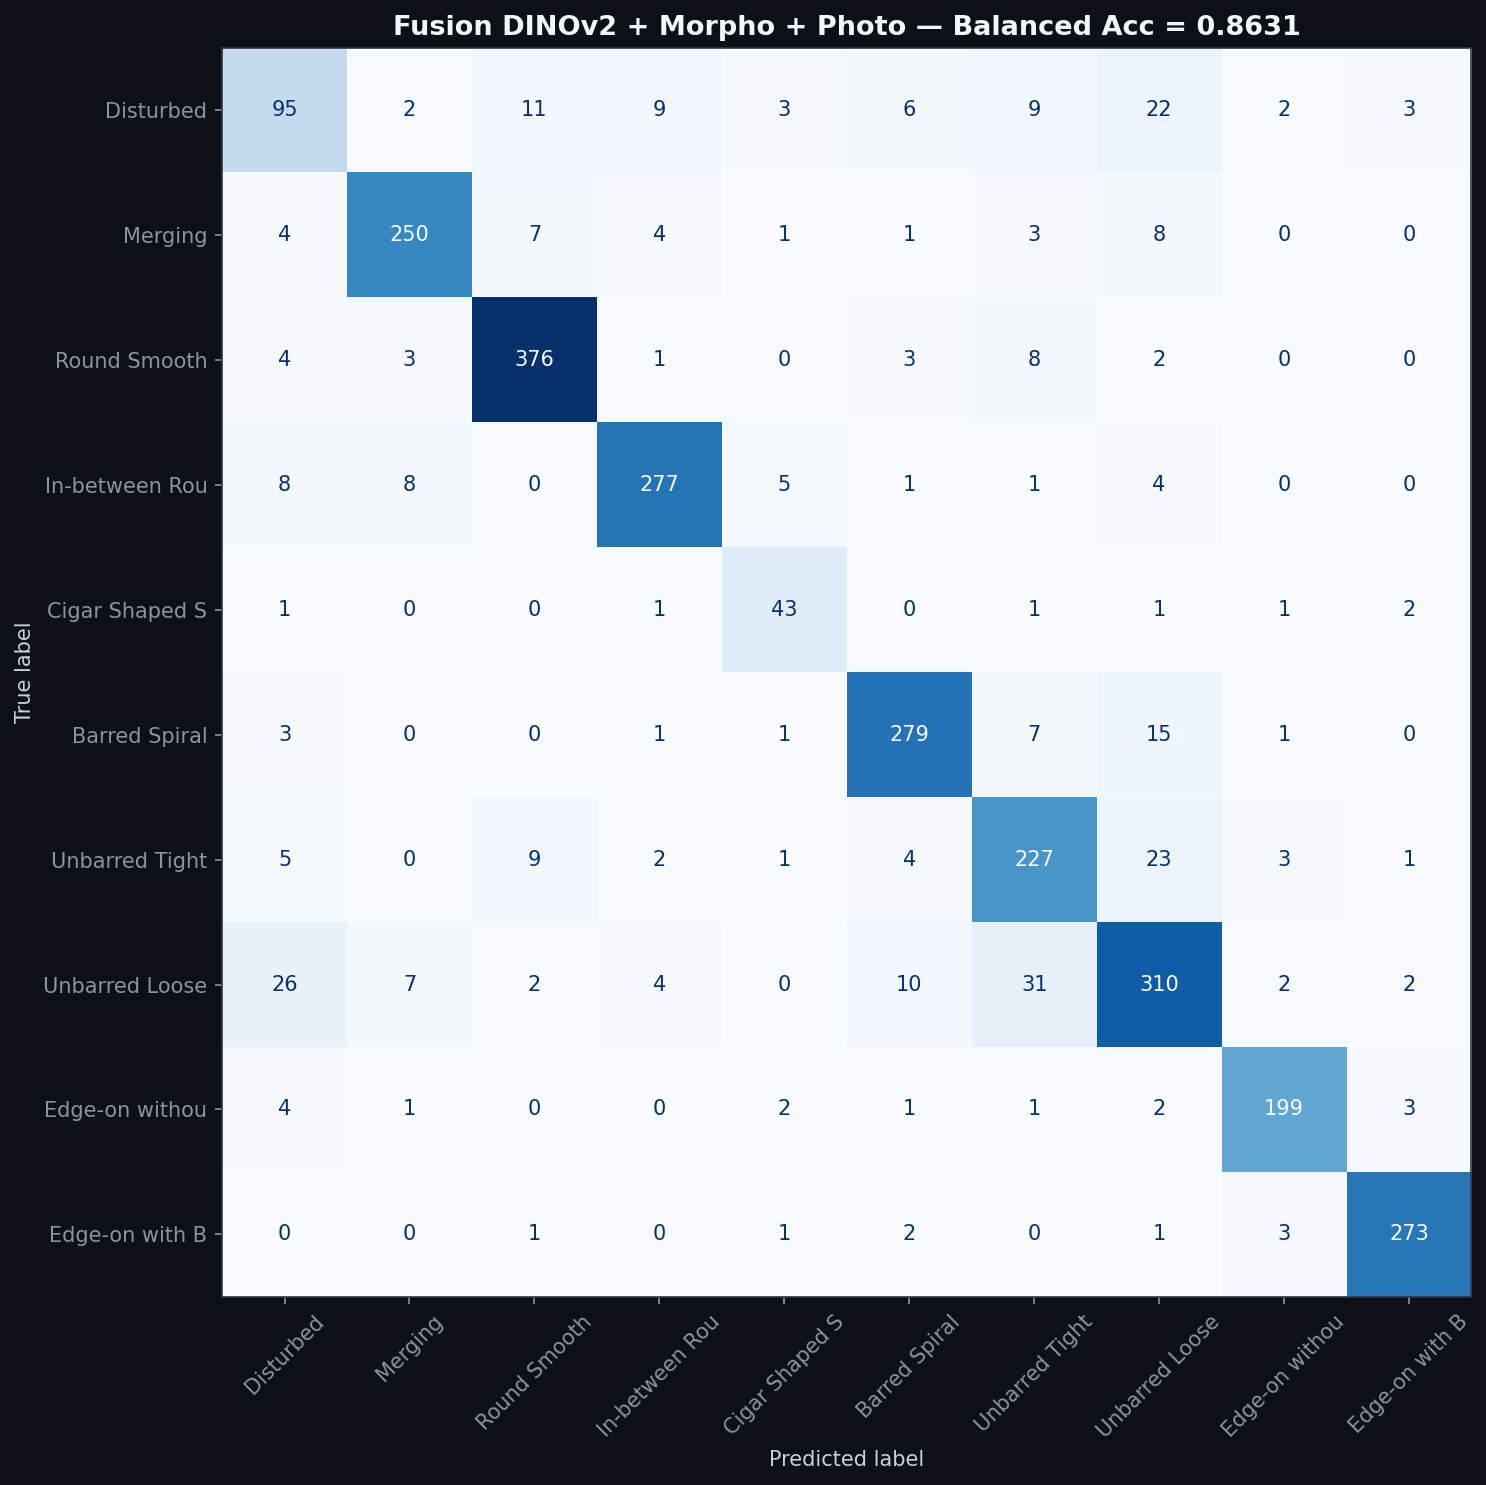

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(
    confusion_matrix=results['confusion'],
    display_labels=[c[:14] for c in CLASS_NAMES]
)
disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)
ax.set_title(f'Fusion DINOv2 + Morpho + Photo — Balanced Acc = {results["balanced_acc"]:.4f}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fusion_confusion.png', dpi=150)
plt.show()

## 6 — Étude d'ablation : quelles modalités apportent quoi ?

In [13]:
ablation_results = ablation_study(
    dino_features, labels_all,
    train_idx, val_idx, test_idx,
    morph_features=morph_features,
    photo_features=photo_features,
    epochs=30,
    device=DEVICE,
)


──────────────────────────────────────────────────
  Ablation : DINOv2 seul
──────────────────────────────────────────────────
════════════════════════════════════════════════════════════
  GalaxyFusionClassifier — DINOv2
  Params : 627,338   Device : cuda
════════════════════════════════════════════════════════════

[★] Epoch 01/30  Train bal=0.7303 loss=1.1968  |  Val bal=0.8642 loss=0.8164
[★] Epoch 02/30  Train bal=0.8452 loss=0.8595  |  Val bal=0.8679 loss=0.7853
[★] Epoch 03/30  Train bal=0.8542 loss=0.8225  |  Val bal=0.8712 loss=0.7765
[ ] Epoch 04/30  Train bal=0.8652 loss=0.8021  |  Val bal=0.8647 loss=0.7755
[ ] Epoch 05/30  Train bal=0.8712 loss=0.7853  |  Val bal=0.8694 loss=0.7751
[★] Epoch 06/30  Train bal=0.8746 loss=0.7704  |  Val bal=0.8748 loss=0.7712
[★] Epoch 07/30  Train bal=0.8767 loss=0.7593  |  Val bal=0.8794 loss=0.7736
[ ] Epoch 08/30  Train bal=0.8828 loss=0.7521  |  Val bal=0.8718 loss=0.7814
[ ] Epoch 09/30  Train bal=0.8859 loss=0.7426  |  Val bal=0.8772

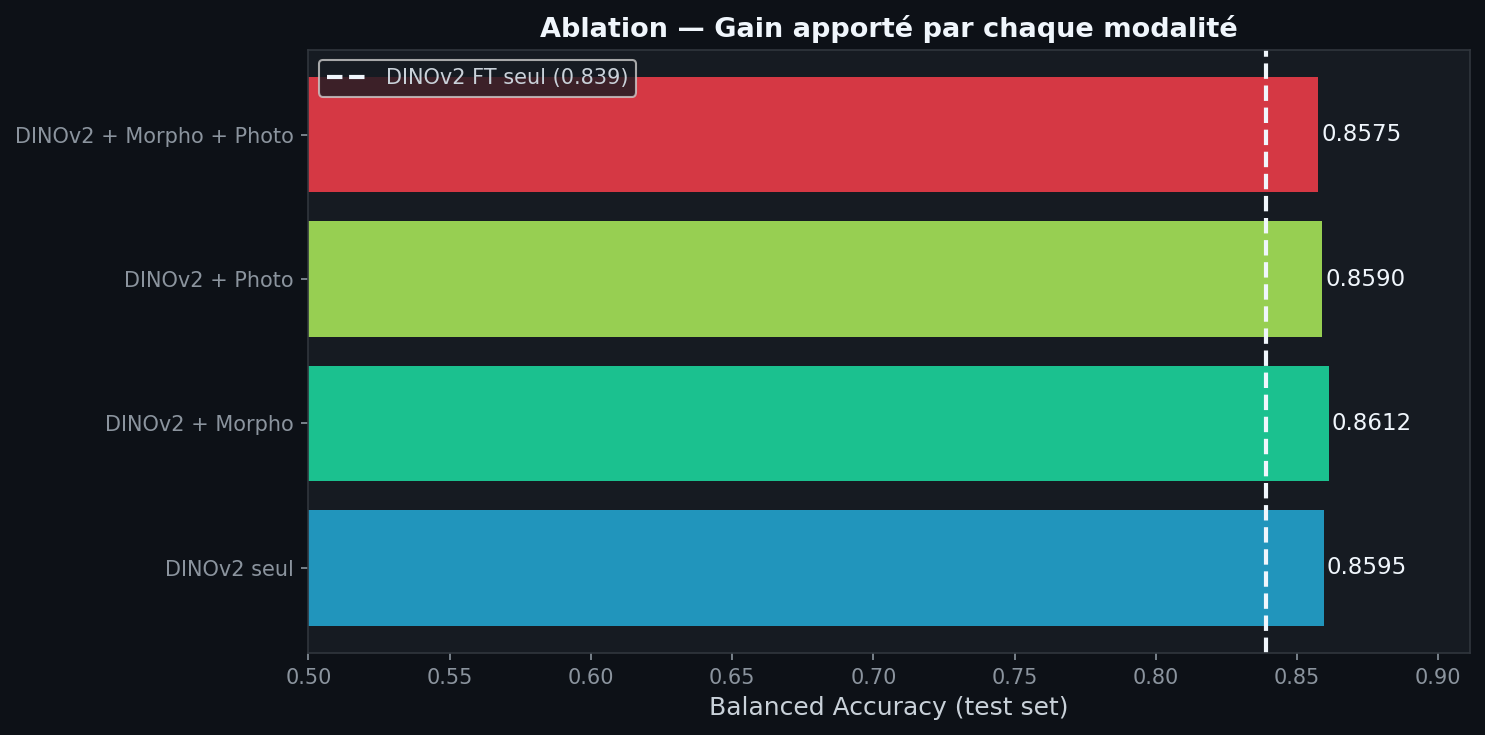


✅ Notebook 08 terminé !


In [14]:
# Figure d'ablation
fig, ax = plt.subplots(figsize=(10, 5))
names   = list(ablation_results.keys())
accs    = list(ablation_results.values())
colors  = ['#23abd8', '#1ddfa3', '#aff05b', '#f83e4b'][:len(names)]

bars = ax.barh(names, accs, color=colors, alpha=0.85)
ax.axvline(0.839, color='#f0f6fc', ls='--', lw=2, label='DINOv2 FT seul (0.839)')
for bar, acc in zip(bars, accs):
    ax.text(acc + 0.001, bar.get_y() + bar.get_height()/2,
            f'{acc:.4f}', va='center', fontsize=11, color='#f0f6fc')
ax.set_xlabel('Balanced Accuracy (test set)', fontsize=12)
ax.set_title('Ablation — Gain apporté par chaque modalité', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim(0.5, min(1.0, max(accs) + 0.05))
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fusion_ablation.png', dpi=150)
plt.show()
print('\n✅ Notebook 08 terminé !')

## 7 — Analyse des erreurs résiduelles

Quelles galaxies résistent à la fusion multi-modale ?

In [15]:
preds   = results['preds']
targets = results['targets']
probs   = results['probs']

# Galaxies mal classées avec haute confiance
max_conf    = probs.max(axis=1)
errors_mask = preds != targets
high_conf_errors = errors_mask & (max_conf > 0.8)

print(f'Erreurs totales        : {errors_mask.sum():,} / {len(targets):,}')
print(f'Erreurs haute confiance (>0.8) : {high_conf_errors.sum():,}')
print()

# Distribution des erreurs par classe
print('Erreurs par classe vraie :')
for i, cls in enumerate(CLASS_NAMES):
    n_total = (targets == i).sum()
    n_err   = errors_mask[targets == i].sum()
    if n_total > 0:
        print(f'  {cls:<35} {n_err:>4}/{n_total:>5}  ({n_err/n_total*100:5.1f}%)')

Erreurs totales        : 332 / 2,661
Erreurs haute confiance (>0.8) : 144

Erreurs par classe vraie :
  Disturbed                             67/  162  ( 41.4%)
  Merging                               28/  278  ( 10.1%)
  Round Smooth                          21/  397  (  5.3%)
  In-between Round Smooth               27/  304  (  8.9%)
  Cigar Shaped Smooth                    7/   50  ( 14.0%)
  Barred Spiral                         28/  307  (  9.1%)
  Unbarred Tight Spiral                 48/  275  ( 17.5%)
  Unbarred Loose Spiral                 84/  394  ( 21.3%)
  Edge-on without Bulge                 14/  213  (  6.6%)
  Edge-on with Bulge                     8/  281  (  2.8%)


## 8 — Sauvegarde


In [16]:
import torch, json

# Sauvegarder les résultats d'ablation
with open(DATA_DIR / 'fusion_ablation_results.json', 'w') as f:
    json.dump(ablation_results, f, indent=2)

print('✓ Résultats ablation sauvegardés')
print(f'✓ Meilleur modèle : {CKPT_DIR}/fusion_dinov2_morpho_photo_best.pt')

✓ Résultats ablation sauvegardés
✓ Meilleur modèle : ..\checkpoints/fusion_dinov2_morpho_photo_best.pt


## Conclusions

| Configuration | Balanced Acc | Delta vs DINOv2 |
|---|---|---|
| DINOv2 FT seul (référence) | 0.839 | — |
| + Morphométrie | à mesurer | — |
| + Photométrie SDSS | à mesurer | — |
| + Morphométrie + Photométrie | à mesurer | — |

**Note :** Le gain de la photométrie est limité au sous-ensemble SDSS (31.9% du dataset).
Les données manquantes sont masquées dans le forward pass — le modèle apprend à
exploiter les modalités disponibles sans être pénalisé par les NaN.